# Preparation

In [ ]:
# Dependencies 
import os 
import numpy as np 
import pandas as pd 
from math import sqrt 


#Visaulization
from pylab import *
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt 
import seaborn as sns 

#Statistics 
from statistics import median 
from scipy import signal 
from scipy.special import factorial 
from scipy import stats
from scipy.stats import sem,binom,lognorm , poisson, bernoulli,spearmanr
from scipy.fftpack import fft, fftshift 

#Scikit-learn for Machine Learning models 
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split

#Read in csv of Toy Dataset 
#we will use this dataset throughout the tutorial 
df = pd.read_csv(r"D:\Daily_Class\April\29th, 30th- Advanced stats\COMPLETED STATISTICS PRACTICLE\toy_dataset.csv")


# Discrete and Continuous Variables

In [ ]:
#PMF Visualization 

n = 100
p =0.5

fig, ax = plt.subplots(1,1, figsize=(17,5))
x = np.arange(binom.ppf(0.01, n, p), binom.ppf(0.99, n, p))
ax.plot(x, binom.pmf(x, n, p), 'bo', ms=8, label="Binomial PMF")
ax.vlines(x,0,binom.pmf(x,n,p),colors='b',lw=5, alpha=0.5)
rv = binom(n,p)

#ax.vlines(x,0,rv.pmf(x), colors='k',linestyles='-', lw =1, label'frozen'
ax.legend(loc='best',frameon=False,fontsize='xx-large')
plt.title('PMF of a binomial distribution (n=100,p=0.5)',fontsize='xx-large')
plt.show()

        

# PDF(Probability Density Functions )

In [ ]:
#plot normal ditribution 
mu = 0
variance = 1
sigma = sqrt(variance)
x = np.linspace(mu -3*sigma, mu + 3*sigma, 100)
plt.figure(figsize=(16,5))
plt.plot(x, stats.norm.pdf(x,mu,sigma),label="Normal Distribution")
plt.grid(True)
plt.title("Normal Distribution with mean = 0 and std =1")
plt.legend(fontsize="xx-large")
plt.show()

# CDF (Cumulative Distribution Function)

In [ ]:
#Data 
X = np.arange(-2,2,0.01)
Y = exp(-X ** 2)

#Normalize data 
Y = Y/(0.01 * Y).sum()

#Plot the PDF and CDF 
plt.figure(figsize=(15,5))
plt.title("Continuous Normal Distribution", fontsize='xx-large')
plot(X,Y,label='robability Density Function (PDF)')
plot(X,np.cumsum(Y * 0.01),'r',label="Cumulative Distribution Function(CD)")
plt.legend(fontsize='xx-large')
plt.show()
    

# Uniform & Uniform Distribution 

In [ ]:
# Uniform distribution (between 0 and 1)
uniform_dist = np.random.random(1000)
uniform_df = pd.DataFrame({'value': uniform_dist})
uniform_dist = pd.Series(uniform_dist)

In [ ]:
plt.figure(figsize=(18,5))
sns.scatterplot(data=uniform_df)
plt.legend(fontsize='xx-large')
plt.title("Scatterplot of a Random/Uniform Distribution",fontsize="xx-large")

In [ ]:
plt.figure(figsize=(28,5))
sns.distplot(uniform_df)
plt.title("Random/Uniform Distribution", fontsize="xx-large")

# Normal Distribution 

In [ ]:
# Generate Normal Distribution 
normal_dist = np.random.randn(10000)
normal_df = pd.DataFrame({'value': normal_dist})

#Create a Pandas Series for easy sample function 
normal_dist = pd.Series(normal_dist)

normal_dist2 = np.random.randn(10000)
normal_df2 = pd.DataFrame({'value':normal_dist2})

#Create a Pandas Series for easy sample function 
normal_dist2 = pd.Series(normal_dist)
normal_df_total = pd.DataFrame({'value1':normal_dist,
                                'value2': normal_dist2})

In [ ]:
# Scatterplot 
plt.figure(figsize=(18,5))
sns.scatterplot(data=normal_df)
plt.legend(fontsize="xx-large")
plt.title("Scatterplot of a Normal Distribution",fontsize="xx-large")

In [ ]:
# Normal Distribution as a Bell Curve 
plt.figure(figsize=(18,5))
sns.distplot(normal_df)
plt.title("Normal Distribution (n=10000)", fontsize="xx-large")

# Binomial Distribution 

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import bernoulli

# Change of head(outcome 1)
p = 0.6

# Create Bernoulli samples
bern_dist = bernoulli.rvs(p, size=10000)
bern_df = pd.DataFrame({'value': bern_dist})
bern_values = bern_df['value'].value_counts().sort_index()

# Ensure both 0 and 1 exist
heads = bern_values.get(1, 0)
tails = bern_values.get(0, 0)

# Plot Distribution
plt.figure(figsize=(8, 5))
bars = plt.bar(bern_values.index, bern_values.values, color=['skyblue', 'orange'])

# Add annotations on top of bars
for i, value in enumerate(bern_values.values):
    label = "Heads" if bern_values.index[i] == 1 else "Tails"
    plt.text(i, value + 50, f"{label}\nn={value}", ha='center', fontsize=12)

plt.xticks([0, 1], ['Tails (0)', 'Heads (1)'])
plt.title("Bernoulli Distribution: p = 0.6, n = 10000")
plt.ylabel("Frequency")

plt.show()

# Poisson Distribution 

In [ ]:
x = np.arange(0,20,0.1)
y = np.exp(-5)*np.power(5,x)/factorial(x)

plt.figure(figsize=(15,8))
plt.title("Poisson distribution with lambda=5",fontsize="xx-large")
plt.plot(x,y,'bs')
plt.show()

# Log-normal Dsitribution 

In [ ]:
#specify standard deviation and mean 
std = 1
mean = 5

#create log-normal distribution 
dist=lognorm(std,loc=mean)
x=np.linspace(0,15,200)

#Visualize log-normal distribution 
plt.figure(figsize=(15,6))
plt.xlim(5,10)
plt.plot(x,dist.pdf(x),label="log-normal PDF")
plt.plot(x,dist.cdf(x), label="log-normal CDF")
plt.legend(fontsize="xx-large")
plt.title("Visualization of log-normal PDF and CDF", fontsize="xx-large")
plt.show()

# Summary statistics and Moments 

In [20]:
#Summary 
print("Summary Statistics for a normal distribution")
#Median
medi = median(normal_dist)
print('Median: ', medi)
display(normal_df.describe())

# Standard deivation 
std = sqrt(np.var(normal_dist))

print("The first four calculated moments of a normal distributions:")
#Mean
mean = normal_dist.mean()
print('Mean:',mean)

#Variance
var = np.var(normal_dist)
print('Variance:',var)

#Return unbiased skew normalized by N-1
skew = normal_df['value'].skew()
print('Skewness:',skew)

#Return unbiased kurtosis over requested axis using Fisher's definition of Kurtosis 
#(kurtosis of normal == 0.0 )normalized by N-1
kurt = normal_df['value'].kurtosis()
print('Kurtosis:',kurt)

Summary Statistics for a normal distribution
Median:  49.910050034027236


,value
count,10000.000000
mean,-0.017465
std,1.007979
min,-3.635470
25%,-0.705657
50%,-0.011741
75%,0.667879
max,4.370151


The first four calculated moments of a normal distributions:
Mean: 49.93599894034043
Variance: 101.32325920258184
Skewness: 0.01174191808586533
Kurtosis: -0.053430767797480794


# Bias , MSE and SE 

In [21]:
# Take sample 
normal_df_sample = normal_df.sample(100)

# Calculate Expected Value (EV), population mean and bias 
ev = normal_df_sample.mean()[0]
pop_mean = normal_df.mean()[0]
bias = ev - pop_mean


C:\Users\Dell\AppData\Local\Temp\ipykernel_17908\2652251685.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ev = normal_df_sample.mean()[0]
C:\Users\Dell\AppData\Local\Temp\ipykernel_17908\2652251685.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pop_mean = normal_df.mean()[0]


In [22]:
print('Sample mean (Expected Value):', ev)
print('Population mean:',pop_mean)
print('Bias:',bias)

Sample mean (Expected Value): 0.01951290840830171
Population mean: -0.017464786410814195
Bias: 0.036977694819115906


# MSE (Mean Squared Error)

In [23]:
from math import sqrt 

Y = 100 #Actual Value 
YH = 94 #Predicted Value 

#MSE formula 
def MSE(Y, YH):
    return np.square(YH -Y).mean()

#RMSE formula 
def RMSE(Y, YH):
    return sqrt(np.square(YH - Y).mean())

print('MSE:',MSE(Y, YH))

print('RMSE:',RMSE(Y, YH))
                

MSE: 36.0
RMSE: 6.0


# SE (STANDARD ERROR)

In [24]:
# standard error (se)
uni_sample = uniform_dist.sample(100)
norm_sample = normal_dist.sample(100)

print('Standard Error of uniform sample:',sem(uni_sample))
print('Standard Error of normal sample:', sem(norm_sample))

# The random samples from the normal distribution should have a higher standard 

Standard Error of uniform sample: 0.027040084321789393
Standard Error of normal sample: 0.925318411394788


# SAMPLING Methods 

In [25]:
import pandas as pd
import numpy as np

# Create a normal distribution (example)
normal_dist = pd.Series(np.random.normal(loc=50, scale=10, size=10000))

print('---Non-Representative samples:---\n')

# Convenience samples
con_samples = normal_dist[0:5]
print('Convenience samples:\n\n{}\n'.format(con_samples))

# Haphazard samples
hap_samples = [normal_dist[12], normal_dist[55], normal_dist[582]]
print('Haphazard samples:\n\n{}\n'.format(hap_samples))

# Purposive samples (Top 5 values)
purp_samples = normal_dist.nlargest(n=5)
print('Purposive samples:\n\n{}\n'.format(purp_samples))

print('---Representative samples:---\n')

# Random samples
rand_samples = normal_dist.sample(5)
print('Random samples:\n\n{}\n'.format(rand_samples))

# Systematic samples (every 2000th value)
sys_samples = normal_dist[normal_dist.index % 2000 == 0]
print('Systematic samples:\n\n{}\n'.format(sys_samples))

# Stratified Sampling
df = pd.read_csv('toy_dataset.csv')

strat_samples = []
for city in df['City'].unique():
    samp = df[df['City'] == city].sample(1)
    strat_samples.append(samp['Income'].item())

print('Stratified samples:\n\n{}\n'.format(strat_samples))

# Cluster Sampling
c1 = normal_dist.sample(10)
c2 = normal_dist.sample(10)
c3 = normal_dist.sample(10)
c4 = normal_dist.sample(10)
c5 = normal_dist.sample(10)

print('Cluster samples:\n')
print('Cluster 1:\n{}\n'.format(c1))
print('Cluster 2:\n{}\n'.format(c2))
print('Cluster 3:\n{}\n'.format(c3))
print('Cluster 4:\n{}\n'.format(c4))
print('Cluster 5:\n{}\n'.format(c5))


---Non-Representative samples:---

Convenience samples:

0    38.856112
1    42.094287
2    68.522194
3    55.887110
4    52.975455
dtype: float64

Haphazard samples:

[np.float64(55.863119013224406), np.float64(41.862260245041824), np.float64(60.76150280608351)]

Purposive samples:

2625    85.441707
6489    84.016677
2309    83.470004
4308    82.858712
1927    82.349185
dtype: float64

---Representative samples:---

Random samples:

2608    65.853101
7527    48.493162
4180    51.485323
4478    63.332635
9982    51.620812
dtype: float64

Systematic samples:

0       38.856112
2000    46.454906
4000    39.318725
6000    38.250717
8000    17.610896
dtype: float64



FileNotFoundError: [Errno 2] No such file or directory: 'toy_dataset.csv'

In [26]:
# Covraince between Age and Income 
print('Covariance between Age and Income: ')

df[['Age','Income']].cov()

Covariance between Age and Income: 


,Age,Income
Age,133.922426,-3.811863e+02
Income,-381.186341,6.244752e+08


# Correlation 

In [27]:
# Correlation between two normal distributions
#Using  Pearson's correlation 
# Pearson correlation (DataFrame)
print('Pearson:')
print(df[['Age','Income']].corr(method='pearson'))

# Negatively correlated data (same length)
x1 = [1,3,3,4,6,7,7,9,10,10]
x2 = [2.2,9.3,6,7,7.2,6,4.2,4.5,4,3]

# Positively correlated data (same length)
y1 = [0,1,2,2.3,3,4,4,7,9,9.5]
y2 = [2.2,4,3,5,5.3,5,7,7,9,5]

# Correlation with NumPy
print('\nx1,x2 correlation: \n', np.corrcoef(x1,x2))
print('\ny1,y2 correlation: \n', np.corrcoef(y1,y2))

Pearson:
             Age    Income
Age     1.000000 -0.001318
Income -0.001318  1.000000

x1,x2 correlation: 
 [[ 1.         -0.31264554]
 [-0.31264554  1.        ]]

y1,y2 correlation: 
 [[1.         0.73288021]
 [0.73288021 1.        ]]


In [28]:
# Using Spearman's rho correaltion 
print('Spearman:')
df[['Age','Income']].corr(method='spearman')

Spearman:


,Age,Income
Age,1.000000,-0.001452
Income,-0.001452,1.000000


# Linear Regression 

<Axes: title={'center': 'Well fitted but not well fitting: Linear Regression plot on quadrant'}>

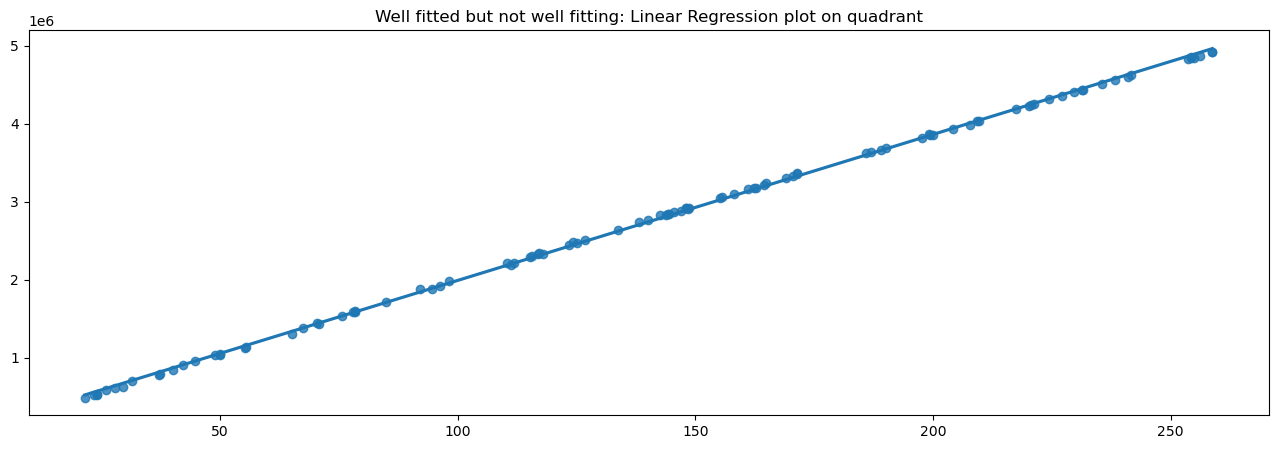

In [30]:
# Generate data 
x = np.random.uniform(low = 20,high=260,size=100)
y = 50000 + 20000*x - 4.5 * x**2 +np.random.normal(size=100, loc=0,scale=10000)

# Plot data with linear regression
plt.figure(figsize=(16,5))
plt.title("Well fitted but not well fitting: Linear Regression plot on quadrant")
sns.regplot(x=x, y=y)

Slope:-55.86086916352489
Intercept: 758.070937888479


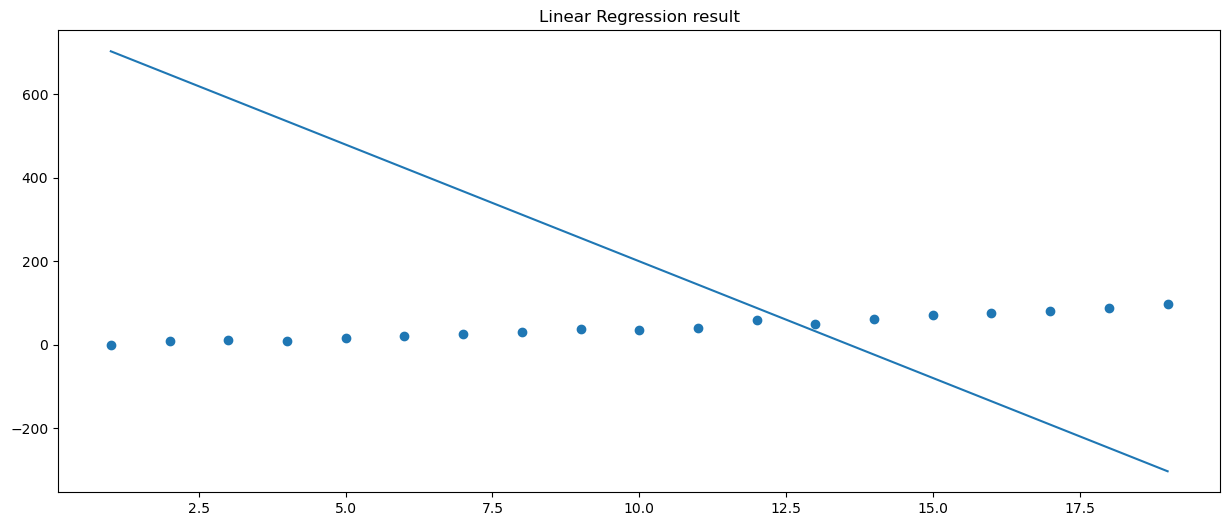

In [33]:
# Linear regresiion from scratch 
import random 
# Create data from regression 
xs = np.array(range(1,20))
ys = [0,8,10,8,15,20,26,29,38,35,40,60,50,61,70,75,80,88,96]

# Put data in dictionary 
data = dict()
for i in list(xs):
    data.update({xs[i-1]:ys[i-1]})

# Slape 
m = 0
# y intercept 
b = 0
# Learning rate 
lr = 0.0001
#Number of epochs 
epochs = 100000

# Formula for Linear Line 
def lin(x):
    return m * x + b 

# Linear regression algorithm 
for i in range(epochs):
    # Pick a random point and calculate vertical distance and horizontal distance 
    rand_point = random.choice(list(data.items()))
    vert_dist = abs((m * rand_point[0] + b) - rand_point[1])
    hor_dist = rand_point[0]

    if (m * rand_point[0] + b) - rand_point[1] < 0:
        # Adjust line upwards 
        m += lr * vert_dist * hor_dist
        b += lr * vert_dist
    else:
        # ADjust line upwards 
        m -= lr * vert_dist * hor_dist
        b += lr * vert_dist

# Plot dat points and regression line 
plt.figure(figsize=(15,6))
plt.scatter(data.keys(), data.values())
plt.plot(xs, lin(xs))
plt.title("Linear Regression result")
print("Slope:{}\nIntercept: {}".format(m,b))
        

# Bootstrapping 

Means of Bootstrap Samples: 
85737     101837.0
52270      87019.0
146629     91216.0
20738      90411.0
134221    100865.0
47652      76763.0
61828      94668.0
77089     111509.0
64400     105154.0
27200      89358.0
Name: Income, dtype: float64

Mean of the population: 91282.03132
Standard Deviation of the population : 25000.819179980703


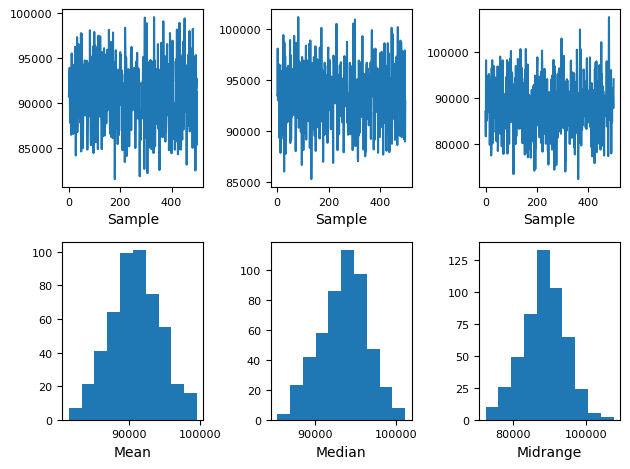

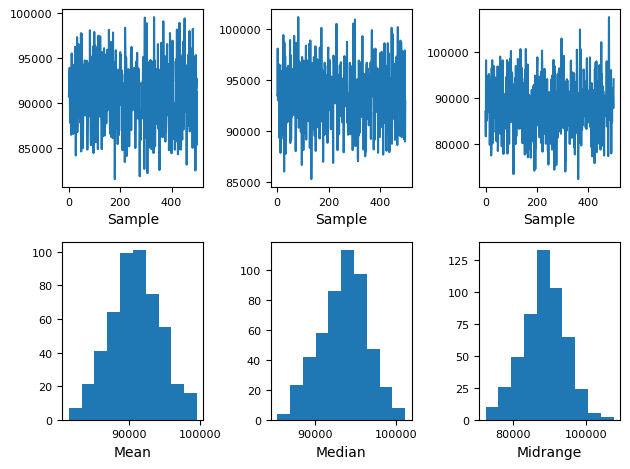

In [36]:
# scikit-learn bootstrap package 
from sklearn.utils import resample

#data sample 
data=df['Income'].sample(100000)

#prepare bootstrap samples 
boot = resample(data, replace=True, n_samples=10, random_state=1)
print("Means of Bootstrap Samples: \n{}\n".format(boot))
print("Mean of the population:",data.mean())
print("Standard Deviation of the population :", data.std())

# Bootstrap plot 
pd.plotting.bootstrap_plot(data)


                

# Hypothesis Testing 
* P-value 

In [39]:
# Perform t-test and compute p value of two random samples 
print("T-statistics nd p-values of two random samples.")

for _ in range(10):
    rand_sample1 = np.random.random_sample(10)
    rand_sample2 = np.random.random_sample(10)
    print(stats.ttest_ind(rand_sample1, rand_sample2))

T-statistics nd p-values of two random samples.
TtestResult(statistic=np.float64(-0.5310174040945731), pvalue=np.float64(0.6018982137898752), df=np.float64(18.0))
TtestResult(statistic=np.float64(0.6557492747067614), pvalue=np.float64(0.5202798569727864), df=np.float64(18.0))
TtestResult(statistic=np.float64(-0.7392858879102921), pvalue=np.float64(0.46926550046168924), df=np.float64(18.0))
TtestResult(statistic=np.float64(-2.009431499468802), pvalue=np.float64(0.05972743587933442), df=np.float64(18.0))
TtestResult(statistic=np.float64(0.31264613352874204), pvalue=np.float64(0.7581427150560044), df=np.float64(18.0))
TtestResult(statistic=np.float64(0.3376929811071654), pvalue=np.float64(0.7395008597311559), df=np.float64(18.0))
TtestResult(statistic=np.float64(0.0747811493745732), pvalue=np.float64(0.9412136680308669), df=np.float64(18.0))
TtestResult(statistic=np.float64(0.19621992700782517), pvalue=np.float64(0.8466363229380143), df=np.float64(18.0))
TtestResult(statistic=np.float64(0

# q-q plt(quantile-quantile plot)

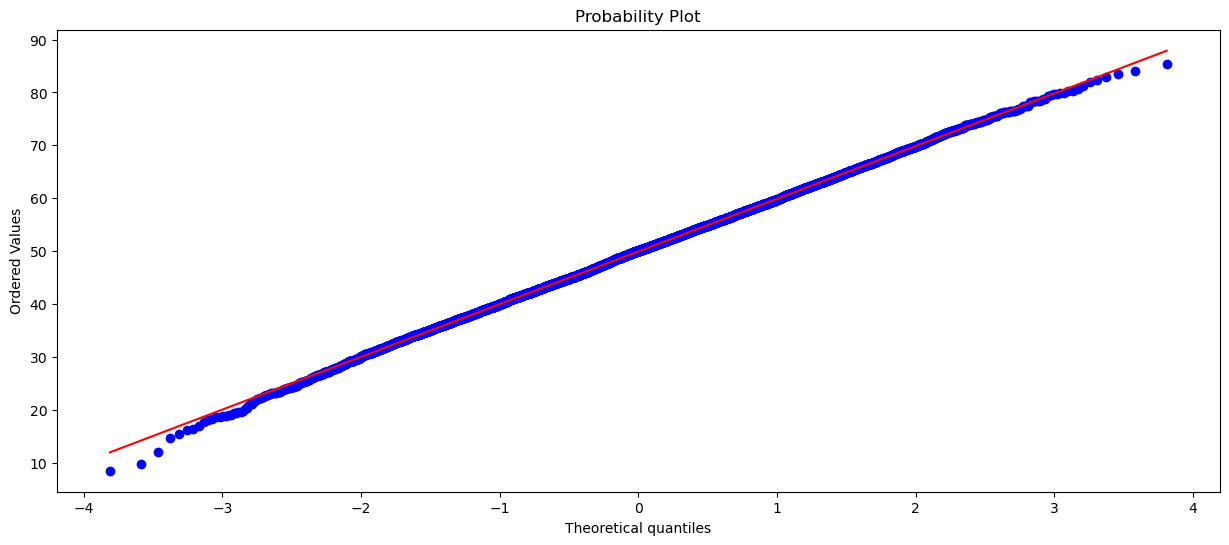

In [40]:
# q-q plot of a normal distribution 
plt.figure(figsize=(15,6))
stats.probplot(normal_dist, dist="norm",plot=plt)
plt.show()

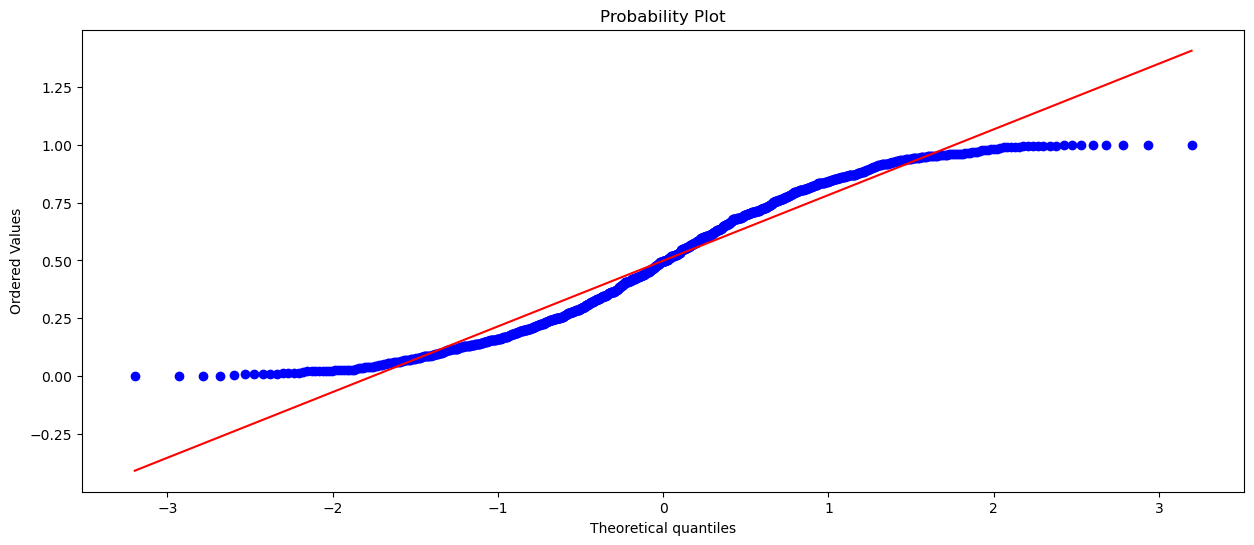

In [41]:
# q-q plot of a uniform/random distribution 
plt.figure(figsize=(15,6))
stats.probplot(uniform_dist, dist="norm", plot=plt)
plt.show()

# Tukey's Method 

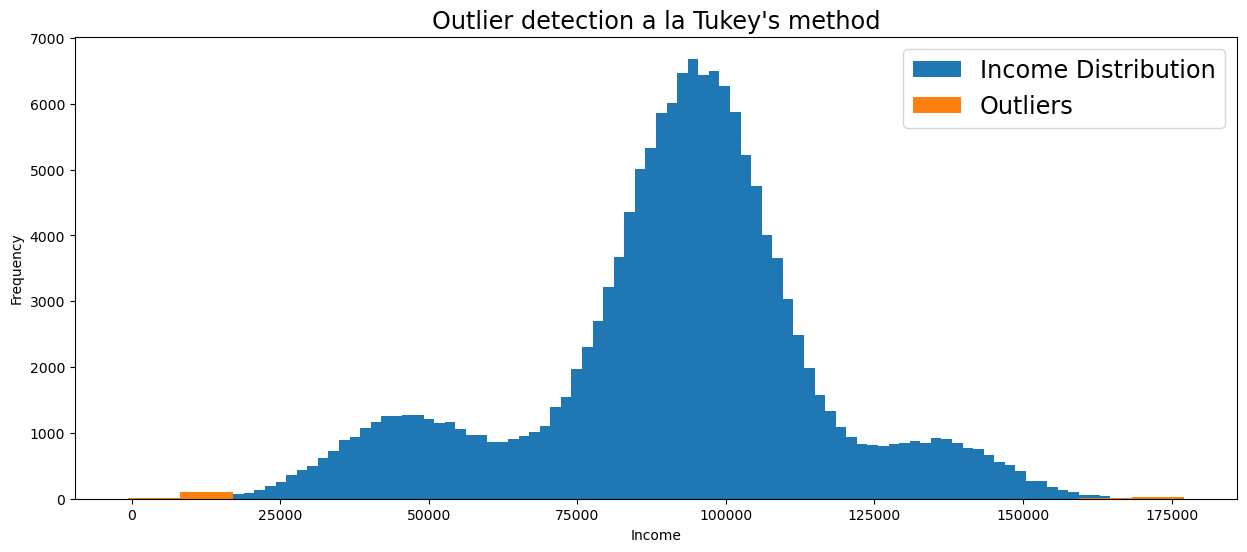

In [43]:
# detect outliers on the 'Income' column of the Toy Dataset 

# Function for detecting outliers a la Tukey's method using z-score 
def tukey_outliers(data) -> list:
    # For more information on calculating the threshold check ut :
    threshold = 3 

    mean = np.mean(data)
    std = np.std(data)

    # Spot and collect outliers 
    outliers = []
    for i in data:
        z_score = (i - mean) / std
        if abs(z_score) > threshold:
            outliers.append(i)
    return outliers

# Get outliers 
income_outliers = tukey_outliers(df['Income'])

# Visualize distribution and outliers 
plt.figure(figsize=(15,6))
df['Income'].plot(kind='hist',bins=100,label='Income Distribution')
plt.hist(income_outliers, bins = 20, label ="Outliers")
plt.title("Outlier detection a la Tukey's method",fontsize="xx-large")
plt.xlabel("Income")
plt.legend(fontsize="xx-large")

# Generalized Linear Models(GLMs)

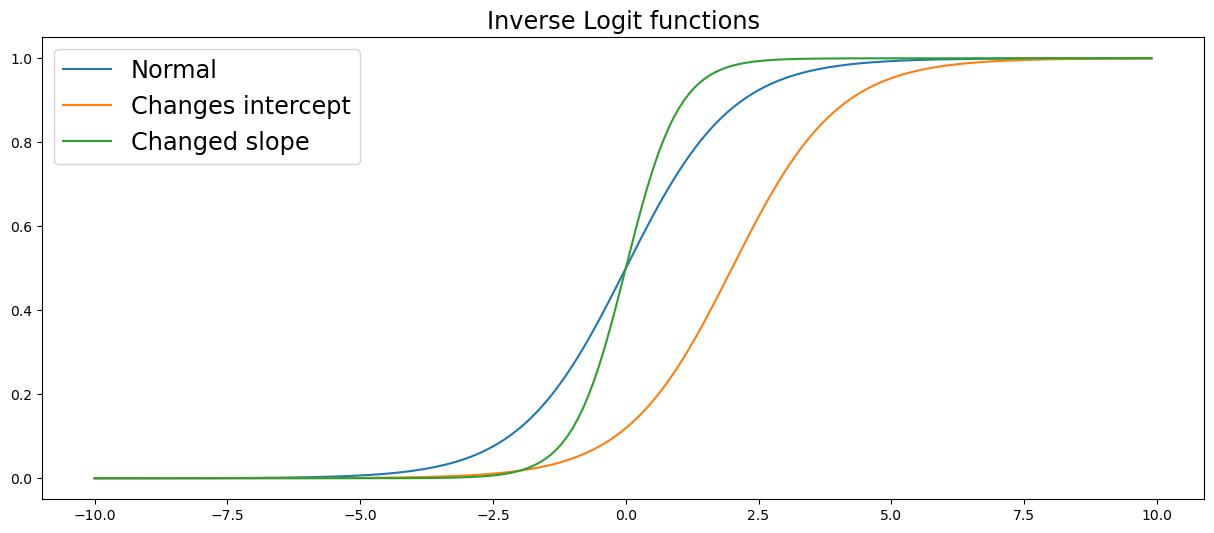

In [47]:
# Inverse Logit function (link function)
def inv_logit(x):
    return 1/(1 +np.exp(-x))

t1 = np.arange(-10,10,0.1)
plt.figure(figsize=(15,6))
plt.plot(t1,inv_logit(t1),
         t1,inv_logit(t1-2),
         t1, inv_logit(t1*2))
plt.title("Inverse Logit functions",fontsize="xx-large")
plt.legend(("Normal","Changes intercept","Changed slope"),fontsize="xx-large")

# Logistic regression 

In [54]:
# Simple example of Logistic Regression in Python 
from sklearn.datasets import load_iris 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)

# Logistic regression classifier 
clf = LogisticRegression(random_state=0,
                         solver='lbfgs',
                         multi_class="multinomial",
                         max_iter=200).fit(X, y)

# Calculate accuracy
y_pred = clf.predict(X)
print("Accuracy score of logistic regression model on the Iris flower dataset:",
      accuracy_score(y, y_pred))

Accuracy score of logistic regression model on the Iris flower dataset: 0.9733333333333334


C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


* Completed the Advanced Statistics 